In [1]:
import os
import pickle
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
from collections import defaultdict
from PIL import Image
import cv2
import gc
from itertools import islice
import networkx as nx
import shapely.geometry as geom
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from shapely.ops import unary_union
from gspan_mining.gspan import gSpan
import community as community_louvain  


In [2]:
# Mapping from RGB color to room type
COLOR_MAPPING = {
    (0xFF, 0xD7, 0x00): 'common_room', 
    (0xFF, 0xA5, 0x00): 'master_room', 
    (0xEE, 0xE8, 0xAA): 'living_room',  
    (0x6B, 0x8E, 0x23): 'balcony',       
    (0xAD, 0xD8, 0xE6): 'bathroom',      
    (0xF0, 0x80, 0x80): 'kitchen',     
    (0xDD, 0xA0, 0xDD): 'storage',      
    (0xDA, 0x70, 0xD6): 'dining',        
}

MIN_AREA_PX = 50

ROOM_LABEL2ID = {rtype: idx for idx, rtype in enumerate(sorted(set(COLOR_MAPPING.values())))}


In [3]:
def segment_room_polygons(image_path):

    img = Image.open(image_path).convert('RGB')
    arr = np.array(img)
    rooms = []

    for color_rgb, rtype in COLOR_MAPPING.items():

        mask = cv2.inRange(arr, np.array(color_rgb), np.array(color_rgb))
        if mask.sum() == 0:
            continue
 
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
        for label in range(1, num_labels):  
            if stats[label, cv2.CC_STAT_AREA] < MIN_AREA_PX:
                continue

            comp_mask = (labels == label).astype(np.uint8) * 255
            contours, _ = cv2.findContours(comp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                if cv2.contourArea(cnt) < MIN_AREA_PX:
                    continue
                # cnt[:, 0, :] is Nx2 array of (x,y)
                coords = cnt.reshape(-1, 2)
                poly = geom.Polygon(coords)
 
                if not poly.is_valid:
                    poly = poly.buffer(0)
                if poly.area < 1.0:
                    continue
                rooms.append({
                    'type': rtype,
                    'polygon': poly,
                    'area': poly.area,
                    'centroid': poly.centroid.coords[0],
                })
    return rooms


# def build_room_graph(rooms, adjacency_thresh=0.0):

#     G = nx.Graph()
#     for idx, room in enumerate(rooms):
#         G.add_node(idx,
#                    room_type=room['type'],
#                    area=room['area'],
#                    centroid=room['centroid'],
#                    polygon=room['polygon'])

#     nodes = list(G.nodes(data=True))
#     for i, (_, di) in enumerate(nodes):
#         for j, (_, dj) in enumerate(nodes[i+1:], start=i+1):
#             pi, pj = di['polygon'], dj['polygon']
#             # adjacency if touching or within threshold distance
#             if pi.touches(pj) or pi.distance(pj) <= adjacency_thresh:
#                 G.add_edge(i, j)
#     return G

def build_room_graph(rooms, adjacency_buffer=6.0):
    G = nx.Graph()
    for idx, room in enumerate(rooms):
        G.add_node(idx,
                   room_type=room['type'],
                   area=room['area'],
                   centroid=room['centroid'],
                   polygon=room['polygon'])
    buffered = {idx: data['polygon'].buffer(adjacency_buffer) for idx, data in G.nodes(data=True)}

    nodes = list(G.nodes())
    for i in nodes:
        for j in nodes:
            if j <= i:
                continue
            if buffered[i].intersects(G.nodes[j]['polygon']):
                G.add_edge(i, j)
    return G


def overlay_polygons(image_path, rooms, figsize=(8,8), alpha=0.4):

    img = np.array(Image.open(image_path).convert('RGB'))
    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()
    for room in rooms:
        poly = room['polygon']

        x, y = poly.exterior.xy
        patch = MplPolygon(list(zip(x, y)), closed=True,
                           facecolor='none', edgecolor='red', linewidth=2, alpha=alpha)
        ax.add_patch(patch)
   
        cx, cy = room['centroid']
        ax.text(cx, cy, room['type'], fontsize=8, ha='center')
    plt.axis('off')
    plt.show()

def overlay_graph(image_path, rooms, graph, figsize=(8,8)):

    img = np.array(Image.open(image_path).convert('RGB'))
    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()


    for room in rooms:
        poly = room['polygon']
        x, y = poly.exterior.xy
        patch = MplPolygon(list(zip(x, y)), closed=True,
                           facecolor='none', edgecolor='red', linewidth=1.5)
        ax.add_patch(patch)

    for u, v in graph.edges():
        x1, y1 = graph.nodes[u]['centroid']
        x2, y2 = graph.nodes[v]['centroid']
        ax.plot([x1, x2], [y1, y2], linewidth=1.5, linestyle='-', color='blue')
    xs = [graph.nodes[n]['centroid'][0] for n in graph.nodes()]
    ys = [graph.nodes[n]['centroid'][1] for n in graph.nodes()]
    ax.scatter(xs, ys, s=30, facecolors='white', edgecolors='black', zorder=3)

    plt.axis('off')
    plt.show()


def process_images(image_dir):
    results = []
    for fname in os.listdir(image_dir):
        if not fname.lower().endswith(('.png','.jpg','.jpeg')):
            continue
        path = os.path.join(image_dir, fname)
        rooms = segment_room_polygons(path)
        G = build_room_graph(rooms)
        results.append({'filename': fname, 'rooms': rooms, 'graph': G})
    return results


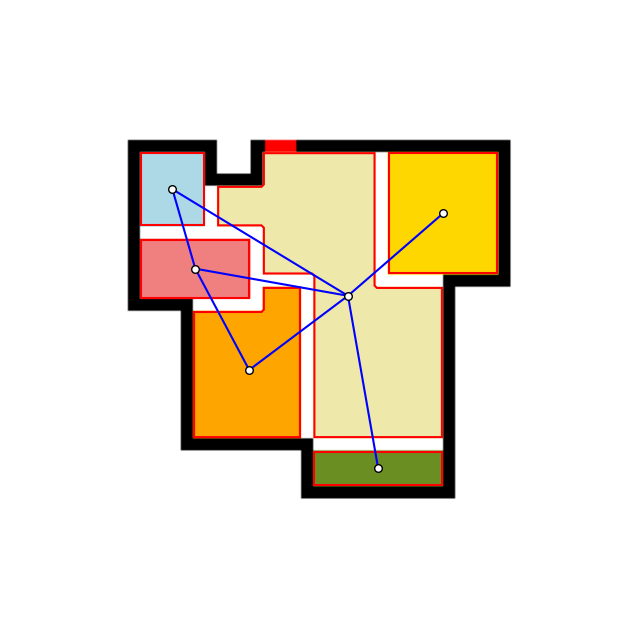

In [4]:
index = 2612
image_path = "./data/Tell2Design Data/General Data/floorplan_image/{}.png".format(index)

rooms = segment_room_polygons(image_path)
G = build_room_graph(rooms)
overlay_graph(image_path, rooms, G)

In [ ]:
image_dir = "./data/Tell2Design Data/General Data/floorplan_image"

graphs = process_images(image_dir)
print(f'Processed {len(graphs)} images into graphs')

In [ ]:
# import pickle

# with open('graphs.pkl', 'wb') as f:
#     pickle.dump(graphs, f)

In [ ]:
import pickle

graphs = pickle.load(open("graphs.pkl", "rb"))

In [ ]:
index = 2612
image_path = "./data/Tell2Design Data/General Data/floorplan_image/{}.png".format(index)

rooms = segment_room_polygons(image_path)
# G = build_room_graph(rooms)
overlay_graph(image_path, rooms, graphs[0]['graph'])

In [ ]:
len(graphs)

In [ ]:
def visualize_graph(G, show_labels=True, figsize=(8,8)):

    pos = {n: d['centroid'] for n, d in G.nodes(data=True)}
    plt.figure(figsize=figsize)
    nx.draw(G, pos, with_labels=show_labels, node_size=300, edge_color='gray', node_color='skyblue')
    plt.axis('equal')
    plt.show()

def visualize_graph_overlay(image_path, G, show_labels=True, figsize=(8,8), alpha=0.7):

    img = Image.open(image_path).convert('RGB')
    arr = np.array(img)
    pos = {n: d['centroid'] for n, d in G.nodes(data=True)}
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr)

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='yellow', alpha=alpha)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=100, node_color='red', alpha=alpha)
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white')
    ax.axis('off')
    plt.show()

In [ ]:
ROOM_LABELS = list(ROOM_LABEL2ID) 
T = len(ROOM_LABELS)

ROOM2IDX = {lbl:i for i,lbl in enumerate(ROOM_LABELS)}

def build_cooccurrence(graphs):
 
    M = np.zeros((T, T), dtype=int)
    for G in graphs:
        for u,v in G.edges():
            tu = G.nodes[u]['room_type']
            tv = G.nodes[v]['room_type']
            i, j = ROOM2IDX[tu], ROOM2IDX[tv]
            M[i, j] += 1
            if i != j:
                M[j, i] += 1
    return M

nx_graphs = [item['graph'] for item in graphs]
cooc = build_cooccurrence(nx_graphs)
cooc

In [ ]:

THRESH = 1000
H = nx.Graph()
for i, ti in enumerate(ROOM_LABELS):
    for j, tj in enumerate(ROOM_LABELS):
        w = cooc[i, j]
        if w >= THRESH and i != j:
            H.add_edge(ti, tj, weight=w)

partition = community_louvain.best_partition(H, weight='weight', resolution=1.5)

clusters = defaultdict(list)
for room, cid in partition.items():
    clusters[cid].append(room)

for cid, members in clusters.items():
    print(f"{cid+1}: {members}")